- {Notebook} [test-on testdataset+qwenemdding+llama](https://www.kaggle.com/code/yangjiahua/test-on-testdataset-qwenemdding-llama)
  - qwen 2.5 14b 모델 사용
- {Notebook} [test-on testdataset+qwenemdding+llama lr](https://www.kaggle.com/code/kishanvavdara/test-on-testdataset-qwenemdding-llama-lr)
  - public score 0.916
- {Model} [lora_14B_GPTQ_1epoch_r32](https://www.kaggle.com/models/yangjiahua/lora_14b_gptq_1epoch_r32)

위 노트북 따라가 보기

- {comment} [comment](https://www.kaggle.com/code/yangjiahua/test-on-testdataset-qwenemdding-llama/comments#3274096)

> 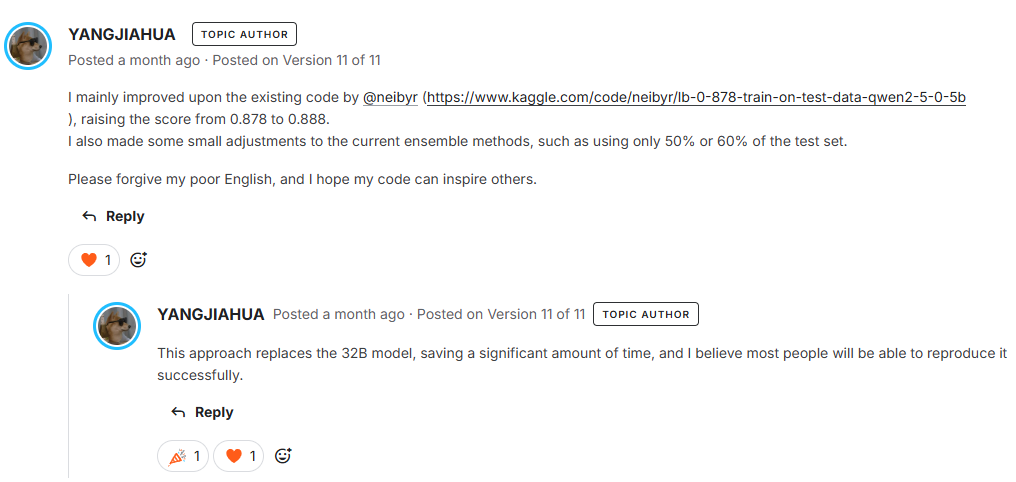

**Version History**

- v2: offline install
- v1: dependency manager

# 1. Environment Setup
- {Notebook} [jigsaw-packages2](https://www.kaggle.com/code/hiranorm/jigsaw-packages2)

In [1]:
!uv pip install --system --no-index --find-links='/kaggle/input/jigsaw-packages2/whls/' 'trl==0.21.0' 'optimum==1.27.0' 'auto-gptq==0.7.1' 'bitsandbytes==0.46.1' 'deepspeed==0.17.4' 'logits-processor-zoo==0.2.1' 'vllm==0.10.0'
!uv pip install --system --no-index --find-links='/kaggle/input/jigsaw-packages2/whls/' 'triton==3.2.0'
!uv pip install --system --no-index --find-links='/kaggle/input/jigsaw-packages2/whls/' 'clean-text'
!uv pip install --system --no-index -U --no-deps --find-links='/kaggle/input/jigsaw-packages2/whls/' 'peft' 'accelerate' 'datasets'

Using Python 3.11.11 environment at: /usr
Resolved 168 packages in 715ms
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17.4
   Building deepspeed==0.17

In [2]:
import os
import pandas as pd
from logits_processor_zoo.vllm import MultipleChoiceLogitsProcessor
import torch
import vllm
import numpy as np
from vllm.lora.request import LoRARequest
import argparse
from scipy.special import softmax

In [3]:
MODEL_NAME = "/kaggle/input/qwen2.5/transformers/14b-instruct-gptq-int4/1"
LORA_PATH = "/kaggle/input/lora_14b_gptq_1epoch_r32/keras/default/1"

os.environ["VLLM_USE_V1"] = "0"

# 2. Prepare Model

In [4]:
llm = vllm.LLM(
    MODEL_NAME,
    # quantization='awq',
    quantization='gptq',
    tensor_parallel_size=torch.cuda.device_count(),
    gpu_memory_utilization=0.98,
    trust_remote_code=True,
    dtype="half",
    enforce_eager=True,
    max_model_len=4096,
    disable_log_stats=True,
    enable_prefix_caching=True,
    enable_lora=True,
    max_lora_rank=32
)
llm

2025-09-26 22:03:46.637680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758924226.962797      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758924227.056187      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


INFO 09-26 22:04:03 [__init__.py:235] Automatically detected platform cuda.


`torch_dtype` is deprecated! Use `dtype` instead!


INFO 09-26 22:04:20 [config.py:1604] Using max model len 4096
WARNING 09-26 22:04:21 [config.py:1084] gptq quantization is not fully optimized yet. The speed can be slower than non-quantized models.
WARNING 09-26 22:04:22 [cuda.py:103] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 09-26 22:04:22 [llm_engine.py:228] Initializing a V0 LLM engine (v0.10.0) with config: model='/kaggle/input/qwen2.5/transformers/14b-instruct-gptq-int4/1', speculative_config=None, tokenizer='/kaggle/input/qwen2.5/transformers/14b-instruct-gptq-int4/1', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=gptq, enforce_eager=True, kv_cache_dtype=auto,  d

2025-09-26 22:04:26.919266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758924266.940513     216 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758924266.946655     216 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


...

INFO 09-26 22:05:04 [__init__.py:1375] Found nccl from library libnccl.so.2
(VllmWorkerProcess pid=216) INFO 09-26 22:05:04 [__init__.py:1375] Found nccl from library libnccl.so.2
INFO 09-26 22:05:04 [pynccl.py:70] vLLM is using nccl==2.26.2
(VllmWorkerProcess pid=216) INFO 09-26 22:05:04 [pynccl.py:70] vLLM is using nccl==2.26.2


[W926 22:05:04.736231726 socket.cpp:200] [c10d] The hostname of the client socket cannot be retrieved. err=-3


INFO 09-26 22:05:04 [custom_all_reduce_utils.py:208] generating GPU P2P access cache in /root/.cache/vllm/gpu_p2p_access_cache_for_0,1.json
INFO 09-26 22:05:28 [custom_all_reduce_utils.py:246] reading GPU P2P access cache from /root/.cache/vllm/gpu_p2p_access_cache_for_0,1.json
(VllmWorkerProcess pid=216) INFO 09-26 22:05:28 [custom_all_reduce_utils.py:246] reading GPU P2P access cache from /root/.cache/vllm/gpu_p2p_access_cache_for_0,1.json
INFO 09-26 22:05:28 [shm_broadcast.py:289] vLLM message queue communication handle: Handle(local_reader_ranks=[1], buffer_handle=(1, 4194304, 6, 'psm_a8da7f4e'), local_subscribe_addr='ipc:///tmp/8358124b-1efd-40d1-a12e-edde49757c14', remote_subscribe_addr=None, remote_addr_ipv6=False)
INFO 09-26 22:05:28 [parallel_state.py:1102] rank 0 in world size 2 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
(VllmWorkerProcess pid=216) INFO 09-26 22:05:28 [parallel_state.py:1102] rank 1 in world size 2 is assigned as DP rank 0, PP rank 0, TP rank 1

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(VllmWorkerProcess pid=216) INFO 09-26 22:06:26 [default_loader.py:262] Loading weights took 57.24 seconds
(VllmWorkerProcess pid=216) INFO 09-26 22:06:26 [logger.py:65] Using PunicaWrapperGPU.
INFO 09-26 22:06:26 [default_loader.py:262] Loading weights took 57.38 seconds
INFO 09-26 22:06:26 [logger.py:65] Using PunicaWrapperGPU.
(VllmWorkerProcess pid=216) INFO 09-26 22:06:27 [model_runner.py:1115] Model loading took 4.8517 GiB and 57.723366 seconds
INFO 09-26 22:06:27 [model_runner.py:1115] Model loading took 4.8517 GiB and 57.861534 seconds
(VllmWorkerProcess pid=216) INFO 09-26 22:06:39 [worker.py:295] Memory profiling takes 11.66 seconds
(VllmWorkerProcess pid=216) INFO 09-26 22:06:39 [worker.py:295] the current vLLM instance can use total_gpu_memory (14.74GiB) x gpu_memory_utilization (0.98) = 14.45GiB
(VllmWorkerProcess pid=216) INFO 09-26 22:06:39 [worker.py:295] model weights take 4.85GiB; non_torch_memory takes 0.12GiB; PyTorch activation peak memory takes 0.39GiB; the rest o

In [5]:
tokenizer = llm.get_tokenizer()
tokenizer

CachedQwen2TokenizerFast(name_or_path='/kaggle/input/qwen2.5/transformers/14b-instruct-gptq-int4/1', vocab_size=151643, model_max_length=131072, is_fast=True, padding_side='right', truncation_side='left', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=F

In [6]:
mclp = MultipleChoiceLogitsProcessor(tokenizer, choices=['Yes','No'])
mclp

# 3. Prepare Prompt

In [7]:
df = pd.read_csv("/kaggle/input/jigsaw-agile-community-rules/test.csv")
print(df.shape)
df.head()

(10, 8)


,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2
0,2029,NEW RAP GROUP 17. CHECK US OUT https://soundcl...,"No Advertising: Spam, referral links, unsolici...",hiphopheads,"Hey, guys, just wanted to drop in and invite y...",Cum Swallowing Hottie Katrina Kaif Cartoon Xvi...,SD Stream Eng - [Chelsea TV USA](http://soccer...,HD Streams: |[ENG HD Stoke vs Manchester Unite...
1,2030,Make your life comfortable. Get up to 15% Disc...,No legal advice: Do not offer or request legal...,AskReddit,Get a lawyer and get the security camera foota...,That isn't drastic. You tried reaching out to ...,So what are you going to do with the insurance...,It's just for Austria & Germany. If you still ...
2,2031,Kickin' ass and selling underwear!\nJust made ...,"No Advertising: Spam, referral links, unsolici...",gonewild,Good story my friend. Check out my blog at ht...,If you know what exactly you need then you don...,CENTIPEDES\n\nSOME BASED PATRIOTS HAVE CREATED...,[So great! Thanks for sharing.](http://www.che...
3,2032,watch hooters best therein http://clickan...,"No Advertising: Spam, referral links, unsolici...",personalfinance,"Earn 50,000 bonus points with Chase Sapphire P...","Cool, front page! I made this print along with...",[Full HD Movie Online Free](http://www.flickma...,* Karambit Black Pearl\n* 0.02137822 Float (un...
4,2033,bitches for free at this point show all h...,"No Advertising: Spam, referral links, unsolici...",Showerthoughts,code free tyrande --->>> [Imgur](http://i.imgu...,My trade link\nhttps://steamcommunity.com/trad...,**HD** [ mio Stadium 102 HD](http://www.genti....,Infographics is an incredible method for showi...


In [8]:
SYS_PROMPT = """
You are given a comment on reddit. Your task is to classify if it violates the given rule. Only respond Yes/No.
"""

In [9]:
prompts = []
for i, row in df.iterrows():
    text = f"""
r/{row.subreddit}
Rule: {row.rule}

1) {row.positive_example_1}
Violation: Yes

2) {row.positive_example_2}
Violation: Yes

3) {row.negative_example_1}
Violation: No

4) {row.negative_example_2}
Violation: No

5) {row.body}
"""
    
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": text}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    ) + "Answer:"
    prompts.append(prompt)

df["prompt"] = prompts
df.shape

(10, 9)

In [10]:
print(df.iloc[0]['prompt'])

<|im_start|>system

You are given a comment on reddit. Your task is to classify if it violates the given rule. Only respond Yes/No.
<|im_end|>
<|im_start|>user

r/hiphopheads
Rule: No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.

1) Hey, guys, just wanted to drop in and invite you to my Pokémon cards/TCG Discord server:  https://discord.gg/S9SbGSe 

Everyone is welcome, and don't forget to bring your love for Pokémon!
Violation: Yes

2) Cum Swallowing Hottie Katrina Kaif Cartoon Xvideo18+
https://youtu.be/0FwHHqCPrag
Violation: Yes

3) SD Stream Eng - [Chelsea TV USA](http://soccerstreamsarena.com/chelsea-u23-vs-tottenham-u23-live-epl2-09-sep-2016/) 

Mobile : Compatible With Android Puffin Browser
Violation: No

4) HD Streams: |[ENG HD Stoke vs Manchester United](http://livesport360.net/stoke-city-vs-manchester-united-2-n2173) Ad Overlays: 1 Mobile: Yes
Violation: No

5) NEW RAP GROUP 17. CHECK US OUT https://soundcloud.com/user-

# 4. Inference

In [11]:
outputs = llm.generate(
    prompts,
    vllm.SamplingParams(
        skip_special_tokens=True,
        max_tokens=1,
        logits_processors=[mclp],
        logprobs=2,
    ),
    use_tqdm=True,
    lora_request=LoRARequest("default", 1, LORA_PATH)
)
len(outputs)

Adding requests:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/10 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

10

In [12]:
outputs[0]

RequestOutput(request_id=0, prompt="<|im_start|>system\n\nYou are given a comment on reddit. Your task is to classify if it violates the given rule. Only respond Yes/No.\n<|im_end|>\n<|im_start|>user\n\nr/hiphopheads\nRule: No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.\n\n1) Hey, guys, just wanted to drop in and invite you to my Pokémon cards/TCG Discord server:  https://discord.gg/S9SbGSe \n\nEveryone is welcome, and don't forget to bring your love for Pokémon!\nViolation: Yes\n\n2) Cum Swallowing Hottie Katrina Kaif Cartoon Xvideo18+\nhttps://youtu.be/0FwHHqCPrag\nViolation: Yes\n\n3) SD Stream Eng - [Chelsea TV USA](http://soccerstreamsarena.com/chelsea-u23-vs-tottenham-u23-live-epl2-09-sep-2016/) \n\nMobile : Compatible With Android Puffin Browser\nViolation: No\n\n4) HD Streams: |[ENG HD Stoke vs Manchester United](http://livesport360.net/stoke-city-vs-manchester-united-2-n2173) Ad Overlays: 1 Mobile: Yes\nViolation: No\n\n

In [13]:
logprobs = [
    {lp.decoded_token: lp.logprob for lp in out.outputs[0].logprobs[0].values()}
    for out in outputs
]
len(logprobs)

10

In [14]:
logprobs[0]

{'No': -0.053237732499837875, 'Yes': -2.9594876766204834}

# 5. Submit

In [15]:
logit_matrix = pd.DataFrame(logprobs)[['Yes','No']]
print(logit_matrix.shape)
logit_matrix.head()

(10, 2)


,Yes,No
0,-2.959488,-0.053238
1,-1.688657,-0.204282
2,-0.151214,-1.963714
3,-0.231798,-1.575548
4,-0.038629,-3.273004


In [16]:
df = pd.concat([df, logit_matrix], axis=1)
print(df.shape)
df.head()

(10, 11)


,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,prompt,Yes,No
0,2029,NEW RAP GROUP 17. CHECK US OUT https://soundcl...,"No Advertising: Spam, referral links, unsolici...",hiphopheads,"Hey, guys, just wanted to drop in and invite y...",Cum Swallowing Hottie Katrina Kaif Cartoon Xvi...,SD Stream Eng - [Chelsea TV USA](http://soccer...,HD Streams: |[ENG HD Stoke vs Manchester Unite...,<|im_start|>system\n\nYou are given a comment ...,-2.959488,-0.053238
1,2030,Make your life comfortable. Get up to 15% Disc...,No legal advice: Do not offer or request legal...,AskReddit,Get a lawyer and get the security camera foota...,That isn't drastic. You tried reaching out to ...,So what are you going to do with the insurance...,It's just for Austria & Germany. If you still ...,<|im_start|>system\n\nYou are given a comment ...,-1.688657,-0.204282
2,2031,Kickin' ass and selling underwear!\nJust made ...,"No Advertising: Spam, referral links, unsolici...",gonewild,Good story my friend. Check out my blog at ht...,If you know what exactly you need then you don...,CENTIPEDES\n\nSOME BASED PATRIOTS HAVE CREATED...,[So great! Thanks for sharing.](http://www.che...,<|im_start|>system\n\nYou are given a comment ...,-0.151214,-1.963714
3,2032,watch hooters best therein http://clickan...,"No Advertising: Spam, referral links, unsolici...",personalfinance,"Earn 50,000 bonus points with Chase Sapphire P...","Cool, front page! I made this print along with...",[Full HD Movie Online Free](http://www.flickma...,* Karambit Black Pearl\n* 0.02137822 Float (un...,<|im_start|>system\n\nYou are given a comment ...,-0.231798,-1.575548
4,2033,bitches for free at this point show all h...,"No Advertising: Spam, referral links, unsolici...",Showerthoughts,code free tyrande --->>> [Imgur](http://i.imgu...,My trade link\nhttps://steamcommunity.com/trad...,**HD** [ mio Stadium 102 HD](http://www.genti....,Infographics is an incredible method for showi...,<|im_start|>system\n\nYou are given a comment ...,-0.038629,-3.273004


In [17]:
df[['Yes',"No"]].head()

,Yes,No
0,-2.959488,-0.053238
1,-1.688657,-0.204282
2,-0.151214,-1.963714
3,-0.231798,-1.575548
4,-0.038629,-3.273004


In [18]:
df[['Yes',"No"]] = df[['Yes',"No"]].apply(lambda x: softmax(x.values), axis=1, result_type="expand")
df[['Yes',"No"]].head()

,Yes,No
0,0.051845,0.948155
1,0.184768,0.815232
2,0.859664,0.140336
3,0.793106,0.206894
4,0.962108,0.037892


In [19]:
df["pred"] = df["Yes"]
df['rule_violation'] = df["pred"]
df[['row_id', 'rule_violation']].to_csv("submission.csv",index=False)

In [20]:
print(df[['row_id', 'rule_violation']].shape)
df[['row_id', 'rule_violation']].head()

(10, 2)


,row_id,rule_violation
0,2029,0.051845
1,2030,0.184768
2,2031,0.859664
3,2032,0.793106
4,2033,0.962108


In [21]:
!head submission.csv

row_id,rule_violation
2029,0.05184546939667006
2030,0.184767510648
2031,0.8596637523076225
2032,0.7931059462938815
2033,0.9621075739136382
2034,0.04401864563031933
2035,0.9441768537603225
2036,0.061875992210939715
2037,0.04023794003402037


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
